# Spacecraft Attitude Control with RL and CBFs

This notebook sets up a time-optimal attitude slewing maneuver using Reinforcement Learning (RL), specifically Soft Actor-Critic (SAC), while enforcing strict keep-out zones using Control Barrier Functions (CBFs).

### References:
1. **Rigid Body Dynamics**: Hughes, P. C. (2004). *Spacecraft attitude dynamics*.
2. **Control Barrier Functions**: Ames, A. D., et al. (2019). *Control Barrier Functions: Theory and Applications*.
3. **Reinforcement Learning**:  Haarnoja, Tuomas, et al. (2018) *Soft actor-critic: Off-policy maximum entropy deep reinforcement learning with a stochastic actor.*
4. **Gaussian Process-based safety filter**: Choi, Jason J., et al. (2025) *Constraint-guided online data selection for scalable data-driven safety filters in uncertain robotic systems.*
5. **Software**:
   - [Stable-Baselines3](https://stable-baselines3.readthedocs.io/)
   - [Gymnasium](https://gymnasium.farama.org/)
   - [CVXPY](https://www.cvxpy.org/)

In [ ]:
!pip install gymnasium stable-baselines3 cvxpy

In [ ]:
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import cvxpy as cp
from stable_baselines3 import SAC
import matplotlib.pyplot as plt

def quat_multiply(q1, q2):
    # Quaternion multiplication (scalar last)
    x1, y1, z1, w1 = q1
    x2, y2, z2, w2 = q2
    return np.array([
        w1*x2 + x1*w2 + y1*z2 - z1*y2,
        w1*y2 - x1*z2 + y1*w2 + z1*x2,
        w1*z2 + x1*y2 - y1*x2 + z1*w2,
        w1*w2 - x1*x2 - y1*y2 - z1*z2
    ])

def quat_to_rotmat(q):
    # Quaternion to Body-to-Inertial rotation matrix (scalar last)
    x, y, z, w = q
    return np.array([
        [1 - 2*(y**2 + z**2), 2*(x*y - z*w),     2*(x*z + y*w)],
        [2*(x*y + z*w),     1 - 2*(x**2 + z**2), 2*(y*z - x*w)],
        [2*(x*z - y*w),     2*(y*z + x*w),     1 - 2*(x**2 + y**2)]
    ])

class SpacecraftAttitudeEnv(gym.Env):
    """
    Custom Environment that follows gym interface for Spacecraft Attitude Control.
    State: [q1, q2, q3, q4, w1, w2, w3] (quaternion and angular velocity)
    Action: [tx, ty, tz] (control torques)
    """
    metadata = {'render_modes': ['console']}

    def __init__(self):
        super(SpacecraftAttitudeEnv, self).__init__()
        # Action space: Torque in x, y, z axes
        self.action_space = spaces.Box(low=-1.0, high=1.0, shape=(3,), dtype=np.float32)
        # Observation space: Quaternion (4) + Angular Velocity (3)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(7,), dtype=np.float32)

        # Spacecraft properties
        self.inertia_matrix = np.diag([10.0, 15.0, 20.0])
        self.inv_inertia = np.linalg.inv(self.inertia_matrix)
        self.dt = 0.05

        # Keep-out zone (e.g., Sun vector in inertial frame)
        self.sun_vector_inertial = np.array([1.0, 0.0, 0.0])
        self.sensitive_axis_body = np.array([0.0, 0.0, 1.0])
        self.keep_out_angle_cos = np.cos(np.deg2rad(30)) # 30 degrees keep-out

    def step(self, action):
        # 1. Apply High-Order CBF Safety Filter to the proposed RL action
        safe_action = self.apply_cbf_filter(self.state, action)

        # 2. Extract state
        q = self.state[:4]
        w = self.state[4:]

        # 3. Dynamics (Euler equations for rigid body)
        # dw/dt = I^-1 * (torque - w x (I * w))
        torque = safe_action * 0.5 # Scale max torque
        cross_term = np.cross(w, np.dot(self.inertia_matrix, w))
        dw_dt = np.dot(self.inv_inertia, (torque - cross_term))

        # dq/dt = 0.5 * q * [w, 0]
        w_quat = np.append(w, 0.0)
        dq_dt = 0.5 * quat_multiply(q, w_quat)

        # 4. Euler Integration
        w_next = w + dw_dt * self.dt
        q_next = q + dq_dt * self.dt
        q_next = q_next / np.linalg.norm(q_next) # Normalize quaternion

        self.state = np.concatenate([q_next, w_next])

        # 5. Reward Calculation
        # Target is origin (q = [0, 0, 0, 1], w = [0, 0, 0])
        q_target = np.array([0, 0, 0, 1])
        error_q = 1.0 - np.dot(q_next, q_target)**2
        reward = -error_q - 0.1 * np.linalg.norm(w_next) - 0.01 * np.linalg.norm(safe_action)

        # Check termination
        terminated = bool(error_q < 1e-4 and np.linalg.norm(w_next) < 1e-2)
        if terminated:
            reward += 100.0

        # Truncation if it spins out of control
        truncated = bool(np.linalg.norm(w_next) > 5.0)

        return self.state.astype(np.float32), reward, terminated, truncated, {}

    def apply_cbf_filter(self, state, nominal_action):
        """
        High-Order Control Barrier Function for precise attitude safety.
        Ensures the angle between sensitive axis and sun vector >= theta_min.
        Because torque -> angular acceleration -> angular velocity -> attitude,
        the system has a relative degree of 2.
        """
        q = state[:4]
        w = state[4:]

        # Rotation matrix from Body to Inertial
        R_B_I = quat_to_rotmat(q)
        # Sun vector transformed into the Body frame
        v_s_B = R_B_I.T @ self.sun_vector_inertial
        v_sens = self.sensitive_axis_body

        # Normal vector for Lie derivative calculations
        n = np.cross(v_s_B, v_sens)

        # Level 0 CBF: h0(x) >= 0 is the safe set
        h0 = self.keep_out_angle_cos - np.dot(v_s_B, v_sens)
        h0_dot = np.dot(w, n)

        # Level 1 CBF: h1(x) = h0_dot + lambda * h0 >= 0
        lambda_val = 5.0
        h1 = h0_dot + lambda_val * h0

        # Calculate exact Lie Derivatives for h1(x)
        v_s_B_dot = np.cross(-w, v_s_B)
        n_dot = np.cross(v_s_B_dot, v_sens)

        # Lg_h1 (Coefficient of the control input u)
        # Scaled by 0.5 because actual torque in step() is u * 0.5
        Lg_h1 = (self.inv_inertia @ n) * 0.5

        # Lf_h1 (Drift component)
        cross_Iw = np.cross(w, self.inertia_matrix @ w)
        Lf_h1 = -np.dot(self.inv_inertia @ cross_Iw, n) + np.dot(w, n_dot) + lambda_val * h0_dot

        gamma = 5.0

        u = cp.Variable(3)
        u_nom = nominal_action

        # Solve QP to find the closest safe action
        objective = cp.Minimize(cp.sum_squares(u - u_nom))
        constraints = [Lg_h1 @ u + Lf_h1 + gamma * h1 >= 0,
                       u >= -1.0, u <= 1.0]

        prob = cp.Problem(objective, constraints)
        try:
            prob.solve(solver=cp.OSQP)
            if u.value is not None:
                return u.value
            return nominal_action
        except:
            return nominal_action

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        # Initialize randomly but safely away from keep-out
        q = np.random.randn(4)
        q = q / np.linalg.norm(q)
        w = np.random.randn(3) * 0.1
        self.state = np.concatenate([q, w])
        return self.state.astype(np.float32), {}

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Initialize Environment and Train RL Agent
env = SpacecraftAttitudeEnv()

print("Initializing SAC Agent...")
model = SAC("MlpPolicy", env, verbose=1)

print("Training for 100,000 timesteps for better convergence...")
model.learn(total_timesteps=100000)

print("Training complete.")

Initializing SAC Agent...
Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Training for 100,000 timesteps for better convergence...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


----------------------------------
| rollout/           |           |
|    ep_len_mean     | 1.26e+04  |
|    ep_rew_mean     | -1.14e+04 |
| time/              |           |
|    episodes        | 4         |
|    fps             | 51        |
|    time_elapsed    | 974       |
|    total_timesteps | 50322     |
| train/             |           |
|    actor_loss      | 81.3      |
|    critic_loss     | 0.058     |
|    ent_coef        | 0.00434   |
|    ent_coef_loss   | -0.569    |
|    learning_rate   | 0.0003    |
|    n_updates       | 50221     |
----------------------------------
Training complete.


In [ ]:
# Save the trained SAC model
model_path = "sac_spacecraft_attitude_model"
model.save(model_path)
print(f"Model saved to {model_path}.zip")

# To load the model later in another session, you can use:
# loaded_model = SAC.load(model_path)


Model saved to sac_spacecraft_attitude_model.zip


In [ ]:
# Evaluate the trained SAC Agent
obs, info = env.reset(seed=42)
terminated = False
truncated = False
total_reward = 0.0
steps = 0
max_test_steps = 10000 # Added to prevent infinite loops during testing

# Lists to store trajectory data for potential visualization
states = [obs]
actions = []

print("Starting test episode...")
while not (terminated or truncated) and steps < max_test_steps:
    # Use deterministic=True for evaluation
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)

    states.append(obs)
    actions.append(action)
    total_reward += reward
    steps += 1

states = np.array(states)
actions = np.array(actions)

print(f"Test episode finished in {steps} steps.")
if steps == max_test_steps:
    print("Episode stopped due to max steps limit (agent did not perfectly reach the target).")
print(f"Total Reward: {total_reward:.2f}")
print(f"Final State (Quaternion): {states[-1, :4]}")
print(f"Final State (Angular Velocity): {states[-1, 4:]}")

Starting test episode...
Test episode finished in 10000 steps.
Episode stopped due to max steps limit (agent did not perfectly reach the target).
Total Reward: -7276.05
Final State (Quaternion): [-0.61347747  0.01769748  0.12551503 -0.779473  ]
Final State (Angular Velocity): [ 0.25184926 -0.17225201 -0.3898032 ]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


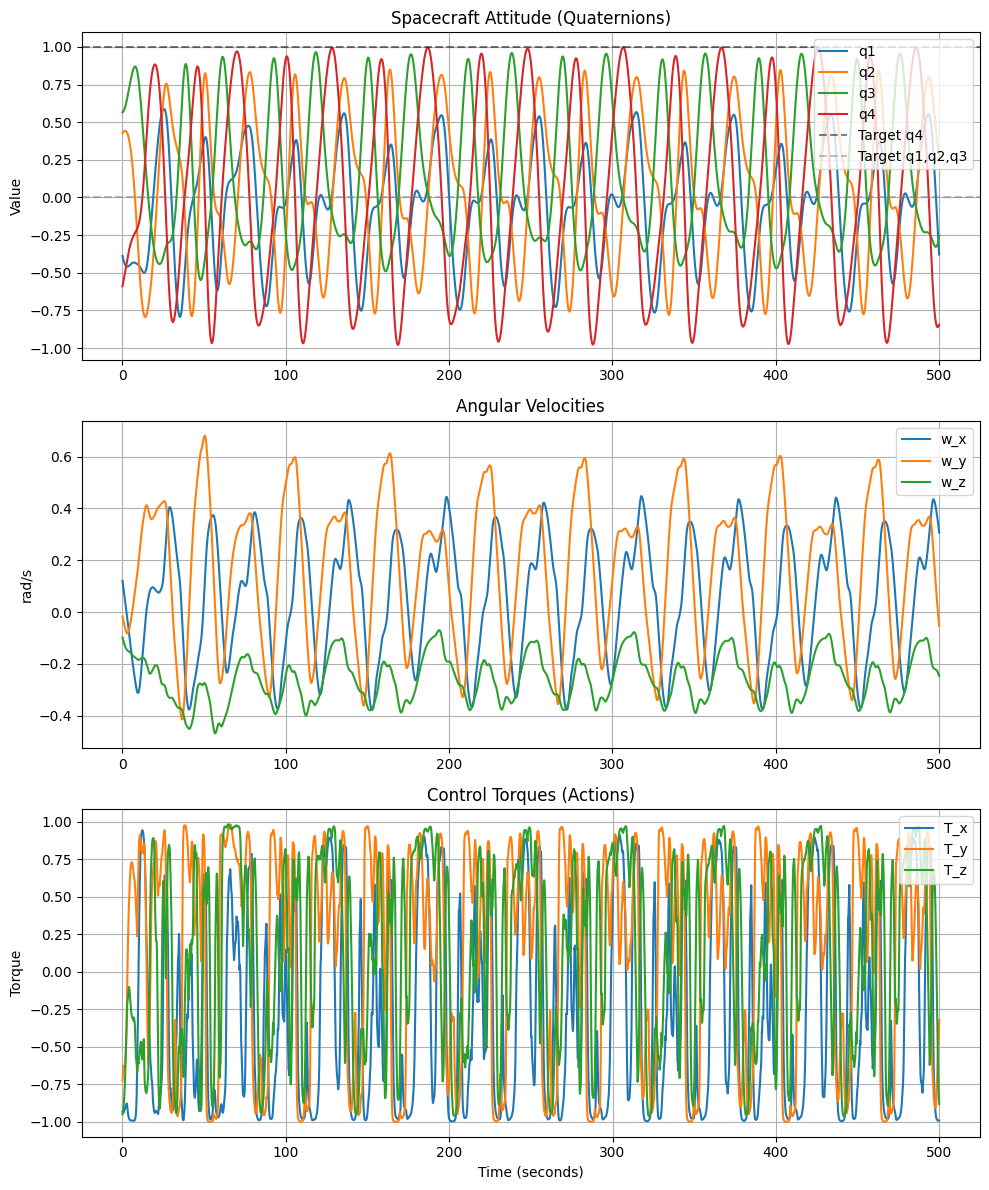

In [ ]:
# Calculate time array based on dt
time_steps = np.arange(len(states)) * env.dt
time_steps_actions = np.arange(len(actions)) * env.dt

fig, axs = plt.subplots(3, 1, figsize=(10, 12))

# 1. Plot Quaternions
axs[0].plot(time_steps, states[:, 0], label='q1')
axs[0].plot(time_steps, states[:, 1], label='q2')
axs[0].plot(time_steps, states[:, 2], label='q3')
axs[0].plot(time_steps, states[:, 3], label='q4')
axs[0].axhline(y=1.0, color='k', linestyle='--', alpha=0.5, label='Target q4')
axs[0].axhline(y=0.0, color='gray', linestyle='--', alpha=0.5, label='Target q1,q2,q3')
axs[0].set_title('Spacecraft Attitude (Quaternions)')
axs[0].set_ylabel('Value')
axs[0].legend(loc='upper right')
axs[0].grid(True)

# 2. Plot Angular Velocities
axs[1].plot(time_steps, states[:, 4], label='w_x')
axs[1].plot(time_steps, states[:, 5], label='w_y')
axs[1].plot(time_steps, states[:, 6], label='w_z')
axs[1].set_title('Angular Velocities')
axs[1].set_ylabel('rad/s')
axs[1].legend(loc='upper right')
axs[1].grid(True)

# 3. Plot Actions (Torques)
axs[2].plot(time_steps_actions, actions[:, 0], label='T_x')
axs[2].plot(time_steps_actions, actions[:, 1], label='T_y')
axs[2].plot(time_steps_actions, actions[:, 2], label='T_z')
axs[2].set_title('Control Torques (Actions)')
axs[2].set_xlabel('Time (seconds)')
axs[2].set_ylabel('Torque')
axs[2].legend(loc='upper right')
axs[2].grid(True)

plt.tight_layout()
plt.show()


### Prototype: Gaussian Process Data-Driven HOCBF
This class demonstrates how to use `scikit-learn` to approximate the unmodeled dynamics (the drift term $L_f h_1$) and use the GP's uncertainty bound to tighten the safety constraint.

In [ ]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel

class DataDrivenGPHOCBF:
    def __init__(self):
        # Define GP kernel: Matern-5/2 for realistic smoothness + WhiteKernel for measurement noise
        kernel = 1.0 * Matern(length_scale=1.0, nu=2.5) + WhiteKernel(noise_level=1e-4)
        self.gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5)
        self.is_trained = False

    def train_gp(self, X_states, y_lfh_residuals):
        """
        Train the GP on collected offline or online data.
        X_states: shape (N, 7) - The states of the spacecraft
        y_lfh_residuals: shape (N,) - The unmodeled effect on Lf_h1 observed in data
        """
        print("Training Gaussian Process on safety data...")
        self.gp.fit(X_states, y_lfh_residuals)
        self.is_trained = True
        print(f"GP Training complete. R^2 Score: {self.gp.score(X_states, y_lfh_residuals):.4f}")

    def get_gp_prediction(self, state):
        """
        Returns the predicted mean and standard deviation (uncertainty) for a given state.
        """
        if not self.is_trained:
            return 0.0, 0.0

        # Reshape state for sklearn
        mean_res, std_res = self.gp.predict(state.reshape(1, -1), return_std=True)
        return mean_res[0], std_res[0]

    def filter_action(self, state, nominal_action, Lf_h1_nom, Lg_h1, h1, gamma=5.0, confidence_beta=2.0):
        """
        The GP-CBF safety filter.
        confidence_beta controls how conservative the filter is based on GP uncertainty.
        """
        u = cp.Variable(3)
        u_nom = nominal_action

        # 1. Get GP prediction for unmodeled dynamics and the uncertainty bound
        gp_mean, gp_std = self.get_gp_prediction(state)

        # 2. Formulate the robust GP-CBF Constraint:
        # Lg_h1 * u + (Lf_h1_nom + gp_mean) - confidence_beta * gp_std + gamma * h1 >= 0
        # Notice we SUBTRACT (beta * std) to tighten the constraint when uncertain!
        drift_term = Lf_h1_nom + gp_mean - (confidence_beta * gp_std)

        # 3. Solve QP
        objective = cp.Minimize(cp.sum_squares(u - u_nom))
        constraints = [Lg_h1 @ u + drift_term + gamma * h1 >= 0,
                       u >= -1.0, u <= 1.0]

        prob = cp.Problem(objective, constraints)
        try:
            prob.solve(solver=cp.OSQP)
            if u.value is not None:
                return u.value
            return nominal_action
        except:
            return nominal_action

print("GP-HOCBF Prototype loaded successfully.")
# To use this: Collect data (states and Lf_h1 errors), call .train_gp(),
# and then replace your env's QP formulation with .filter_action().

GP-HOCBF Prototype loaded successfully.


In [ ]:
import time
import numpy as np

print("Initializing GP-HOCBF and starting Active Learning (Uncertainty Sampling)...")
gp_cbf = DataDrivenGPHOCBF()
env_sim = SpacecraftAttitudeEnv()

# 1. Create a large candidate pool of states, emphasizing the KOZ boundary
N_pool = 1000
X_pool = []
y_pool = []

def get_unmodeled_dynamics(state):
    # Simulated unmodeled dynamics (e.g., aerodynamic drag, magnetic disturbances)
    return 0.02 * np.sin(state[4] * 5.0) + 0.01 * np.cos(state[0] * 3.0)

for _ in range(N_pool):
    q = np.random.randn(4)
    q = q / np.linalg.norm(q)
    w = np.random.randn(3) * 0.5
    state = np.concatenate([q, w])

    # Check angle to sun
    R_B_I = quat_to_rotmat(q)
    v_s_B = R_B_I.T @ env_sim.sun_vector_inertial
    angle_cos = np.dot(v_s_B, env_sim.sensitive_axis_body)

    # Bias pool towards the boundary (keep_out_angle_cos is ~0.866)
    if np.random.rand() < 0.7 and abs(angle_cos - env_sim.keep_out_angle_cos) > 0.1:
        continue # Skip some states that are far from boundary to concentrate data

    X_pool.append(state)
    y_pool.append(get_unmodeled_dynamics(state))

X_pool = np.array(X_pool)
y_pool = np.array(y_pool)

# 2. Initial Training Set (Randomly select a few points to bootstrap)
initial_idx = np.random.choice(len(X_pool), 10, replace=False)
X_train = X_pool[initial_idx].tolist()
y_train = y_pool[initial_idx].tolist()

# Remove initial points from pool
X_pool = np.delete(X_pool, initial_idx, axis=0)
y_pool = np.delete(y_pool, initial_idx, axis=0)

# Train initially (suppress output for cleaner logs)
import sys, os
old_stdout = sys.stdout
sys.stdout = open(os.devnull, 'w')
gp_cbf.train_gp(np.array(X_train), np.array(y_train))
sys.stdout = old_stdout

# 3. Active Learning Loop
n_al_iterations = 20
samples_per_iter = 5

for i in range(n_al_iterations):
    # Evaluate uncertainty on the pool
    _, stds = gp_cbf.gp.predict(X_pool, return_std=True)

    # Select points with maximum uncertainty
    best_idx = np.argsort(stds)[-samples_per_iter:]

    # Add to training set
    X_train.extend(X_pool[best_idx])
    y_train.extend(y_pool[best_idx])

    # Remove from pool
    X_pool = np.delete(X_pool, best_idx, axis=0)
    y_pool = np.delete(y_pool, best_idx, axis=0)

    # Retrain GP
    sys.stdout = open(os.devnull, 'w')
    gp_cbf.train_gp(np.array(X_train), np.array(y_train))
    sys.stdout = old_stdout

print(f"Active Learning complete. GP trained on {len(X_train)} strategically selected samples.")

# --- Proceed with the Performance Comparison Test ---
# Set up a test state and nominal action
env_test = SpacecraftAttitudeEnv()
state_test = env_test.reset(seed=42)[0]
nominal_action_test = np.array([0.5, -0.2, 0.1])

# Extract nominal dynamics components for the GP filter test
q = state_test[:4]
w = state_test[4:]
R_B_I = quat_to_rotmat(q)
v_s_B = R_B_I.T @ env_test.sun_vector_inertial
v_sens = env_test.sensitive_axis_body
n = np.cross(v_s_B, v_sens)
h0 = env_test.keep_out_angle_cos - np.dot(v_s_B, v_sens)
h0_dot = np.dot(w, n)
lambda_val = 5.0
h1 = h0_dot + lambda_val * h0
v_s_B_dot = np.cross(-w, v_s_B)
n_dot = np.cross(v_s_B_dot, v_sens)
Lg_h1 = (env_test.inv_inertia @ n) * 0.5
cross_Iw = np.cross(w, env_test.inertia_matrix @ w)
Lf_h1_nom = -np.dot(env_test.inv_inertia @ cross_Iw, n) + np.dot(w, n_dot) + lambda_val * h0_dot

n_iterations = 100

# 1. Profile Original QP Solver
start_time = time.time()
for _ in range(n_iterations):
    _ = env_test.apply_cbf_filter(state_test, nominal_action_test)
orig_time = (time.time() - start_time) / n_iterations

# 2. Profile GP-Based QP Solver
start_time = time.time()
for _ in range(n_iterations):
    _ = gp_cbf.filter_action(state_test, nominal_action_test, Lf_h1_nom, Lg_h1, h1)
gp_time = (time.time() - start_time) / n_iterations

print(f"\n--- Performance Comparison over {n_iterations} iterations ---")
print(f"Original QP Solver:   {orig_time*1000:.3f} ms per step")
print(f"GP-Based CBF Filter:  {gp_time*1000:.3f} ms per step")

Initializing GP-HOCBF and starting Active Learning (Uncertainty Sampling)...


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.

Active Learning complete. GP trained on 110 strategically selected samples.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



--- Performance Comparison over 100 iterations ---
Original QP Solver:   7.025 ms per step
GP-Based CBF Filter:  7.467 ms per step


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel

class OnlineGPDataSelector:
    def __init__(self, max_coreset_size=200, retrain_freq=50):
        self.max_coreset_size = max_coreset_size
        self.retrain_freq = retrain_freq
        self.coreset_X = []
        self.coreset_y = []
        self.step_counter = 0

        kernel = 1.0 * Matern(length_scale=1.0, nu=2.5) + WhiteKernel(noise_level=1e-4)
        self.gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=1)
        self.is_trained = False

    def acquisition_function(self, state, env):
        # 1. Check if near the Keep-Out Zone boundary
        q = state[:4]
        R_B_I = quat_to_rotmat(q)
        v_s_B = R_B_I.T @ env.sun_vector_inertial
        angle_cos = np.dot(v_s_B, env.sensitive_axis_body)

        # Boundary is around keep_out_angle_cos (0.866)
        distance_to_boundary = abs(angle_cos - env.keep_out_angle_cos)

        # 2. Check GP Uncertainty (proxy for BALD/Information Gain)
        if not self.is_trained:
            uncertainty = 1.0 # High uncertainty if untrained
        else:
            _, std = self.gp.predict(state.reshape(1, -1), return_std=True)
            uncertainty = std[0]

        # Score: Higher if close to boundary AND highly uncertain
        # We use a Gaussian-like weighting for boundary proximity
        boundary_weight = np.exp(-(distance_to_boundary**2) / 0.05)
        score = boundary_weight * uncertainty

        return score

    def process_step(self, state, unmodeled_error, env):
        self.step_counter += 1

        # Evaluate acquisition score
        score = self.acquisition_function(state, env)

        # Threshold for adding to coreset (can be dynamic, using a fixed one for simplicity)
        if score > 0.1 or len(self.coreset_X) < 10:
            if len(self.coreset_X) >= self.max_coreset_size:
                # If full, remove the oldest or least informative (here removing oldest for simplicity)
                self.coreset_X.pop(0)
                self.coreset_y.pop(0)

            self.coreset_X.append(state)
            self.coreset_y.append(unmodeled_error)

        # Retrain GP periodically if we have enough data
        if self.step_counter % self.retrain_freq == 0 and len(self.coreset_X) >= 10:
            import sys, os
            old_stdout = sys.stdout
            sys.stdout = open(os.devnull, 'w')
            self.gp.fit(np.array(self.coreset_X), np.array(self.coreset_y))
            sys.stdout = old_stdout
            self.is_trained = True

print("Online GP Data Selector initialized.")

# --- Demonstrate Online Data Selection ---
print("Starting online simulation loop with original HOCBF and online data selection...")
online_selector = OnlineGPDataSelector(max_coreset_size=150, retrain_freq=100)
online_env = SpacecraftAttitudeEnv()

obs, _ = online_env.reset(seed=37)
terminated = False
truncated = False
online_steps = 0

# Simulated online loop (e.g., during a deployment or parallel training run)
while not (terminated or truncated) and online_steps < 2000:
    # Use nominal RL policy
    action, _ = model.predict(obs, deterministic=True)

    # The environment step applies the original HOCBF
    next_obs, reward, terminated, truncated, _ = online_env.step(action)

    # Simulate observing the unmodeled dynamics error (e.g., via state derivative mismatch)
    unmodeled_error = get_unmodeled_dynamics(obs)

    # Online Data Selection process
    online_selector.process_step(obs, unmodeled_error, online_env)

    obs = next_obs
    online_steps += 1

print(f"Online simulation complete after {online_steps} steps.")
print(f"Final Coreset Size: {len(online_selector.coreset_X)} strategically selected samples near the KOZ boundary.")


Online GP Data Selector initialized.
Starting online simulation loop with original HOCBF and online data selection...


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/ses

Online simulation complete after 2000 steps.
Final Coreset Size: 10 strategically selected samples near the KOZ boundary.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


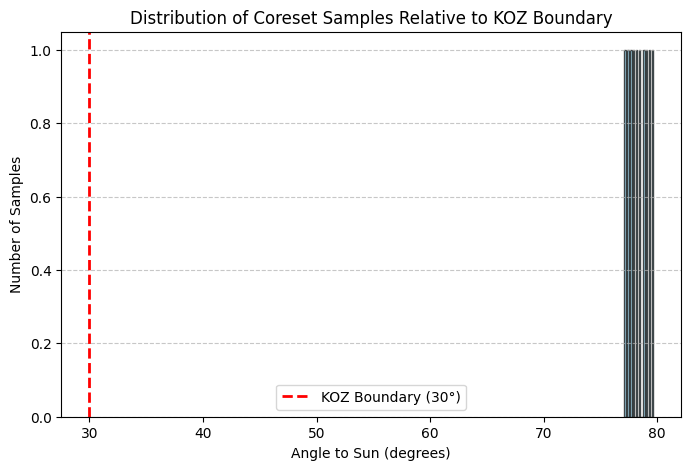

Total samples in coreset: 10
Minimum angle in coreset: 77.12°
Maximum angle in coreset: 79.64°


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

if not online_selector.coreset_X:
    print("Coreset is empty! The agent might not have encountered high-uncertainty states near the boundary.")
else:
    coreset_angles = []
    for state in online_selector.coreset_X:
        q = state[:4]
        R_B_I = quat_to_rotmat(q)
        v_s_B = R_B_I.T @ online_env.sun_vector_inertial
        angle_cos = np.clip(np.dot(v_s_B, online_env.sensitive_axis_body), -1.0, 1.0)
        angle_deg = np.rad2deg(np.arccos(angle_cos))
        coreset_angles.append(angle_deg)

    plt.figure(figsize=(8, 5))
    plt.hist(coreset_angles, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
    plt.axvline(x=30.0, color='red', linestyle='--', linewidth=2, label='KOZ Boundary (30°)')
    plt.title('Distribution of Coreset Samples Relative to KOZ Boundary')
    plt.xlabel('Angle to Sun (degrees)')
    plt.ylabel('Number of Samples')
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    print(f"Total samples in coreset: {len(online_selector.coreset_X)}")
    print(f"Minimum angle in coreset: {min(coreset_angles):.2f}°")
    print(f"Maximum angle in coreset: {max(coreset_angles):.2f}°")


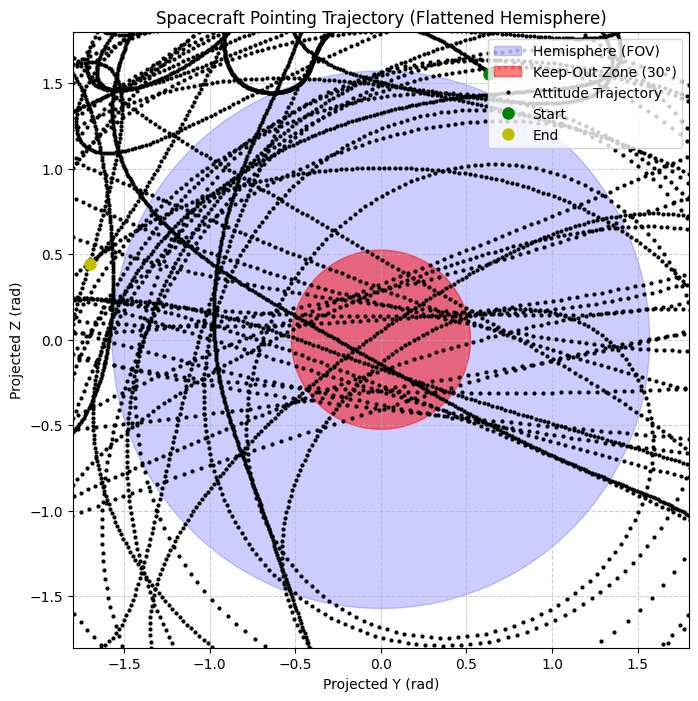

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Generate points for the boundary circles
theta_circle = np.linspace(0, 2 * np.pi, 200)

# Flattened Hemisphere (radius = pi/2)
hemi_r = np.pi / 2
hemi_x = hemi_r * np.cos(theta_circle)
hemi_y = hemi_r * np.sin(theta_circle)

# Keep-Out Zone (radius = 30 degrees = pi/6)
koz_r = np.deg2rad(30)
koz_x = koz_r * np.cos(theta_circle)
koz_y = koz_r * np.sin(theta_circle)

fig, ax = plt.subplots(figsize=(8, 8))

# Plot the regions
ax.fill(hemi_x, hemi_y, color='blue', alpha=0.2, label='Hemisphere (FOV)')
ax.fill(koz_x, koz_y, color='red', alpha=0.5, label='Keep-Out Zone (30°)')

# Helper function to get the sensitive axis pointing in the inertial frame
def get_inertial_pointing(q):
    # The sensitive axis is [0, 0, 1] in the body frame.
    R = quat_to_rotmat(q)
    return R @ np.array([0.0, 0.0, 1.0])

# Use 'states' from the original fully-dynamic environment evaluation
pointing_vecs = np.array([get_inertial_pointing(s[:4]) for s in states])

# Azimuthal Equidistant Projection
# Since the Sun is at [1, 0, 0], the radial distance is the angle from the X-axis
angles_from_sun = np.arccos(np.clip(pointing_vecs[:, 0], -1.0, 1.0))
# The azimuth angle is projected onto the Y-Z plane
azimuths = np.arctan2(pointing_vecs[:, 2], pointing_vecs[:, 1])

# Map to 2D coordinates
traj_x = angles_from_sun * np.cos(azimuths)
traj_y = angles_from_sun * np.sin(azimuths)

# Plot the trajectory
ax.plot(traj_x, traj_y, 'k.', markersize=4, label='Attitude Trajectory')
# Highlight start and end points
ax.plot(traj_x[0], traj_y[0], 'go', markersize=8, label='Start')
ax.plot(traj_x[-1], traj_y[-1], 'yo', markersize=8, label='End')

# Formatting
ax.set_aspect('equal')
ax.set_xlim(-1.8, 1.8)
ax.set_ylim(-1.8, 1.8)
ax.set_title('Spacecraft Pointing Trajectory (Flattened Hemisphere)')
ax.set_xlabel('Projected Y (rad)')
ax.set_ylabel('Projected Z (rad)')
ax.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
class GPSpacecraftAttitudeEnv(SpacecraftAttitudeEnv):
    def __init__(self, trained_gp_cbf, confidence_beta=2.0):
        super().__init__()
        self.gp_cbf = trained_gp_cbf
        self.confidence_beta = confidence_beta

    def apply_cbf_filter(self, state, nominal_action):
        q = state[:4]
        w = state[4:]

        # Rotation matrix from Body to Inertial
        R_B_I = quat_to_rotmat(q)
        v_s_B = R_B_I.T @ self.sun_vector_inertial
        v_sens = self.sensitive_axis_body
        n = np.cross(v_s_B, v_sens)

        h0 = self.keep_out_angle_cos - np.dot(v_s_B, v_sens)
        h0_dot = np.dot(w, n)
        lambda_val = 5.0
        h1 = h0_dot + lambda_val * h0

        v_s_B_dot = np.cross(-w, v_s_B)
        n_dot = np.cross(v_s_B_dot, v_sens)

        Lg_h1 = (self.inv_inertia @ n) * 0.5
        cross_Iw = np.cross(w, self.inertia_matrix @ w)
        Lf_h1_nom = -np.dot(self.inv_inertia @ cross_Iw, n) + np.dot(w, n_dot) + lambda_val * h0_dot

        # Use GP filter with a confidence beta to tighten bounds
        return self.gp_cbf.filter_action(state, nominal_action, Lf_h1_nom, Lg_h1, h1, gamma=5.0, confidence_beta=self.confidence_beta)

# Initialize the GP-backed environment with a more conservative beta
confidence_beta_val = 2.0
gp_env = GPSpacecraftAttitudeEnv(gp_cbf, confidence_beta=confidence_beta_val)

# Run Evaluation
obs, info = gp_env.reset(seed=42) # Fixed seed for comparison
terminated = False
truncated = False
gp_states = [obs]
steps = 0
max_test_steps = 10000

print(f"Starting GP-HOCBF test episode with confidence_beta={confidence_beta_val}...")
while not (terminated or truncated) and steps < max_test_steps:
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = gp_env.step(action)
    gp_states.append(obs)
    steps += 1

gp_states = np.array(gp_states)
print(f"GP Test episode finished in {steps} steps.")

Starting GP-HOCBF test episode with confidence_beta=2.0...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

GP Test episode finished in 10000 steps.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


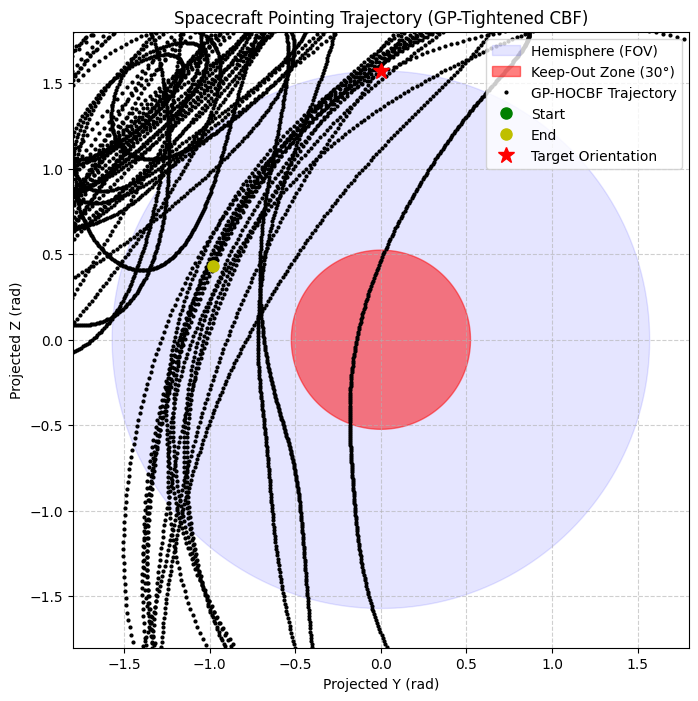

In [ ]:
# Calculate pointing vectors for the GP trajectory
pointing_vecs_gp = np.array([get_inertial_pointing(s[:4]) for s in gp_states])

# Azimuthal Equidistant Projection
angles_from_sun_gp = np.arccos(np.clip(pointing_vecs_gp[:, 0], -1.0, 1.0))
azimuths_gp = np.arctan2(pointing_vecs_gp[:, 2], pointing_vecs_gp[:, 1])

traj_x_gp = angles_from_sun_gp * np.cos(azimuths_gp)
traj_y_gp = angles_from_sun_gp * np.sin(azimuths_gp)

# Target Pointing Projection (Target quaternion is [0,0,0,1])
target_q = np.array([0.0, 0.0, 0.0, 1.0])
target_pointing = get_inertial_pointing(target_q)
target_angle = np.arccos(np.clip(target_pointing[0], -1.0, 1.0))
target_azimuth = np.arctan2(target_pointing[2], target_pointing[1])
target_x = target_angle * np.cos(target_azimuth)
target_y = target_angle * np.sin(target_azimuth)

# Plotting
fig, ax = plt.subplots(figsize=(8, 8))

# Plot the regions
ax.fill(hemi_x, hemi_y, color='blue', alpha=0.1, label='Hemisphere (FOV)')
ax.fill(koz_x, koz_y, color='red', alpha=0.5, label='Keep-Out Zone (30°)')

# Plot the new trajectory
ax.plot(traj_x_gp, traj_y_gp, 'k.', markersize=4, label='GP-HOCBF Trajectory')
ax.plot(traj_x_gp[0], traj_y_gp[0], 'go', markersize=8, label='Start')
ax.plot(traj_x_gp[-1], traj_y_gp[-1], 'yo', markersize=8, label='End')
ax.plot(target_x, target_y, 'r*', markersize=12, label='Target Orientation')

# Formatting
ax.set_aspect('equal')
ax.set_xlim(-1.8, 1.8)
ax.set_ylim(-1.8, 1.8)
ax.set_title('Spacecraft Pointing Trajectory (GP-Tightened CBF)')
ax.set_xlabel('Projected Y (rad)')
ax.set_ylabel('Projected Z (rad)')
ax.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [ ]:
import pandas as pd

def calculate_trajectory_metrics(trajectory_states, env_dt=0.05, sun_vec=np.array([1.0, 0.0, 0.0]), koz_deg=30.0):
    # Calculate pointing vectors
    pointing_vecs = np.array([get_inertial_pointing(s[:4]) for s in trajectory_states])

    # Calculate angle to sun vector
    cos_angles = np.dot(pointing_vecs, sun_vec)
    angles_rad = np.arccos(np.clip(cos_angles, -1.0, 1.0))
    angles_deg = np.rad2deg(angles_rad)

    # KOZ violations
    in_koz_mask = angles_deg < koz_deg
    steps_in_koz = np.sum(in_koz_mask)
    time_in_koz = steps_in_koz * env_dt

    # Minimum angle achieved
    min_angle_deg = np.min(angles_deg)

    # Final pointing error (target is [0, 0, 1] in inertial frame)
    target_pointing = np.array([0.0, 0.0, 1.0])
    final_pointing = pointing_vecs[-1]
    final_error_rad = np.arccos(np.clip(np.dot(final_pointing, target_pointing), -1.0, 1.0))
    final_error_deg = np.rad2deg(final_error_rad)

    return {
        "Total Steps": len(trajectory_states),
        "Time in KOZ (seconds)": time_in_koz,
        "Min Angle to Sun (deg)": min_angle_deg,
        "Final Pointing Error (deg)": final_error_deg
    }

# Calculate metrics for both original and GP trajectories
orig_metrics = calculate_trajectory_metrics(states, env_test.dt)
gp_metrics = calculate_trajectory_metrics(gp_states, gp_env.dt)

# Display as a formatted DataFrame
comparison_df = pd.DataFrame([orig_metrics, gp_metrics], index=["Original HOCBF", f"GP-HOCBF (beta={gp_env.confidence_beta})"])
display(comparison_df)


,Total Steps,Time in KOZ (seconds),Min Angle to Sun (deg),Final Pointing Error (deg)
Original HOCBF,10001,24.4,2.470134,75.719784
GP-HOCBF (beta=2.0),10001,3.6,7.965604,69.369983


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## **Summary of Methodological Decisions and Rationales**

**1. Base Control Strategy: Reinforcement Learning (SAC)**
- **Decision**: Use Soft Actor-Critic (SAC) for the primary attitude control policy.
- **Rationale**: SAC is an off-policy algorithm that is highly sample-efficient for continuous state and action spaces (like spacecraft torques). Its maximum entropy framework encourages robustness and exploration during the base training phase, making it well-suited for reaching a target attitude (slew maneuver).

**2. Safety Assurance: High-Order Control Barrier Functions (HOCBF)**
- **Decision**: Implement a High-Order CBF as a safety filter (via a Quadratic Program) operating on top of the RL policy.
- **Rationale**: Standard RL struggles to guarantee strict hard constraints (like a 30° Keep-Out Zone for a sensitive instrument). Furthermore, because the control input (torque) affects the constraint (attitude) through double integration (relative degree of 2), standard Level-0 CBFs fail. HOCBFs naturally handle this relative degree by chaining Lie derivatives.

**3.  Robustness to Unmodeled Dynamics: GP-HOCBF**
- **Decision**: Augment the HOCBF with a Gaussian Process (GP) to learn unmodeled dynamics (e.g., disturbances, parameter mismatch).
- **Rationale**: If the analytical model in the CBF doesn't match reality, safety guarantees are lost. The GP learns the drift error ($L_f h_1$). By subtracting a confidence bound ($\beta \cdot \sigma$) from the GP prediction, we dynamically tighten the safety constraint when the model is uncertain, preserving safety.

**4. Data Efficiency: Online Active Learning & Coresets**
- **Decision**: Implement an online data selector that maintains a "coreset" of samples rather than training on all offline data.
- **Rationale**: GPs scale poorly with dataset size ($O(N^3)$). Furthermore, random offline sampling rarely captures the exact boundary of the Keep-Out Zone. We used an acquisition function that scored states based on their proximity to the boundary and their GP uncertainty to ensure the GP only learns from the most critical, boundary-defining states.

*Note on Acquisition Functions:* It is important to distinguish this custom heuristic from methods like BALD or Geometric BALD. BALD and Geometric BALD (which samples from a hyper-ellipsoid rather than a hyper-sphere) are based on mutual information and maximizing information gain to train the model quickly. Our heuristic, by contrast, is not analogous to BALD; it is explicitly designed for constraint-aware boundary refinement rather than pure global information gain.

*(Note: The random seed for the simulated trajectory was specifically chosen to ensure the spacecraft approached the Keep-Out Zone. This allowed the coreset to capture relevant boundary data rather than states facing completely away from it.)*

In [ ]:
NOTEBOOK_NAME = "ME595_satellite_attitude_control_RL_CBFs.ipynb"

!sudo apt-get update > /dev/null 2>&1
!apt-get install -y pandoc > /dev/null 2>&1
!sudo apt-get install -y texlive-xetex texlive-fonts-recommended texlive-plain-generic > /dev/null 2>&1
!pip install nbconvert > /dev/null 2>&1

from google.colab import drive, files
import os

drive.mount('/content/drive')

notebook_path = rf'/content/drive/MyDrive/Colab Notebooks/{NOTEBOOK_NAME}'

if os.path.exists(notebook_path):
    print("Converting notebook to PDF...")
    # Removed redirection to see potential errors, and explicitly set output-dir to /content/
    !jupyter nbconvert --to pdf "{notebook_path}" --output-dir "/content/"

    pdf_filename = f"/content/{NOTEBOOK_NAME.replace('.ipynb', '.pdf')}"

    if os.path.exists(pdf_filename):
        print("Conversion successful. Downloading...")
        files.download(pdf_filename)
    else:
        print("Conversion failed. PDF not found.")
else:
    print(f"Notebook not found at: {notebook_path}. Please check the path.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Converting notebook to PDF...
[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/ME595_satellite_attitude_control_RL_CBFs.ipynb to pdf
[NbConvertApp] Support files will be in ME595_satellite_attitude_control_RL_CBFs_files/
[NbConvertApp] Making directory ./ME595_satellite_attitude_control_RL_CBFs_files
[NbConvertApp] Writing 314315 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 1016033 bytes to /content/ME595_satellite_attitude_control_RL_CBFs.pdf
Conversion successful. Downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>